In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/FourCastNet_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/FourCastNet_Project


In [3]:
!pip install cdsapi xarray netCDF4 tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 97.9 MB/s eta 0:00:00


In [4]:
import os
import gc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from tqdm import tqdm

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [6]:
from google.colab import userdata

CDSAPI_URL = userdata.get("CDSAPI_URL")
CDSAPI_KEY = userdata.get("CDSAPI_KEY")

with open("/root/.cdsapirc", "w") as f:
    f.write(f"url: {CDSAPI_URL}\n")
    f.write(f"key: {CDSAPI_KEY}\n")

!chmod 600 /root/.cdsapirc

In [7]:
import cdsapi

c = cdsapi.Client()

def download_year(year):

    target = f"{PROJECT_DIR}/era5_antarctica_{year}.nc"

    if os.path.exists(target):
        print(f"{year} already exists")
        return

    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",

            "variable": [
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "2m_temperature",
                "mean_sea_level_pressure"
            ],

            "year": str(year),

            "month": [
                "01","02","03","04",
                "05","06","07","08",
                "09","10","11","12"
            ],

            "day": [
                "01","02","03","04","05","06","07","08","09","10",
                "11","12","13","14","15","16","17","18","19","20",
                "21","22","23","24","25","26","27","28","29","30","31"
            ],

            "time": [
                "00:00",
                "06:00",
                "12:00",
                "18:00"
            ],

            "area": [
                -60,
                50,
                -90,
                100
            ],

            "format": "netcdf"
        },

        target
    )

In [9]:
for year in range(2021, 2026):
    download_year(year)

2021 already exists
2022 already exists
2023 already exists


2026-06-01 18:04:36,641 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

4912ff720a3e3f931064c21ff35a1d3f.nc:   0%|          | 0.00/218M [00:00<?, ?B/s]

2026-06-01 18:05:34,126 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

642cdb8a10d5395ee97e7fab60682a12.nc:   0%|          | 0.00/216M [00:00<?, ?B/s]

In [10]:
import os

PROJECT_DIR = "/content/drive/MyDrive/FourCastNet_Project"

DATA_DIR = f"{PROJECT_DIR}/data"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
LOG_DIR = f"{PROJECT_DIR}/logs"
FIG_DIR = f"{PROJECT_DIR}/figures"
STATS_DIR = f"{PROJECT_DIR}/stats"

for d in [
    DATA_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    FIG_DIR,
    STATS_DIR
]:
    os.makedirs(d, exist_ok=True)

In [13]:
!ls -lh /content/drive/MyDrive/FourCastNet_Project/data

total 0


In [18]:
!find /content/drive/MyDrive -name "*.nc"

/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2021.nc
/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2022.nc
/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2023.nc
/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2024.nc
/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2025.nc


In [20]:
!ls -lh /content/drive/MyDrive/FourCastNet_Project/*.nc

-rw------- 1 root root 216M Jun  1 17:59 /content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2021.nc
-rw------- 1 root root 215M Jun  1 18:02 /content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2022.nc
-rw------- 1 root root 126M Jun  1 18:04 /content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2023.nc
-rw------- 1 root root 218M Jun  1 18:05 /content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2024.nc
-rw------- 1 root root 217M Jun  1 18:06 /content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2025.nc


In [21]:
import xarray as xr

for year in range(2021, 2026):

    file = f"/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_{year}.nc"

    try:
        ds = xr.open_dataset(file)

        print(
            year,
            "OK",
            ds.dims
        )

        ds.close()

    except Exception as e:

        print(
            year,
            "FAILED",
            e
        )

2021 OK FrozenMappingWarningOnValuesAccess({'valid_time': 1460, 'latitude': 121, 'longitude': 201})
2022 OK FrozenMappingWarningOnValuesAccess({'valid_time': 1460, 'latitude': 121, 'longitude': 201})
2023 FAILED [Errno -101] NetCDF: HDF error: '/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2023.nc'
2024 OK FrozenMappingWarningOnValuesAccess({'valid_time': 1464, 'latitude': 121, 'longitude': 201})
2025 OK FrozenMappingWarningOnValuesAccess({'valid_time': 1460, 'latitude': 121, 'longitude': 201})


In [22]:
import os

bad_file = "/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2023.nc"

if os.path.exists(bad_file):
    os.remove(bad_file)

print("Deleted corrupted 2023 file")

Deleted corrupted 2023 file


In [23]:
download_year(2023)

2026-06-01 18:19:34,918 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

22c7c2534ade61a64f96c613b083b3c8.nc:   0%|          | 0.00/215M [00:00<?, ?B/s]

In [24]:
import xarray as xr

ds = xr.open_dataset(
    "/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2023.nc"
)

print(ds.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 1460, 'latitude': 121, 'longitude': 201})


In [25]:
ds = xr.open_mfdataset(
    [
        "/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2021.nc",
        "/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2022.nc",
        "/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2023.nc",
        "/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2024.nc",
        "/content/drive/MyDrive/FourCastNet_Project/era5_antarctica_2025.nc",
    ],
    combine="by_coords"
)

print(ds.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 7304, 'latitude': 121, 'longitude': 201})


In [26]:
import numpy as np

u10 = ds["u10"].values.astype(np.float32)
v10 = ds["v10"].values.astype(np.float32)
t2m = ds["t2m"].values.astype(np.float32)
msl = ds["msl"].values.astype(np.float32)

data = np.stack(
    [u10, v10, t2m, msl],
    axis=1
)

data = data[:, :, :120, :200]

print(data.shape)
print(data.dtype)

(7304, 4, 120, 200)
float32


In [29]:
del u10
del v10
del t2m
del msl
del ds

import gc
gc.collect()

NameError: name 'u10' is not defined

In [28]:
means = data.mean(axis=(0,2,3))
stds = data.std(axis=(0,2,3))

for i in range(4):
    data[:, i] = (
        data[:, i] - means[i]
    ) / stds[i]

In [30]:
means = data.mean(axis=(0,2,3))
stds = data.std(axis=(0,2,3))

for i in range(4):
    data[:, i] = (
        data[:, i] - means[i]
    ) / stds[i]

In [31]:
for i in range(4):
    print(
        data[:,i].mean(),
        data[:,i].std()
    )

-1.3651574e-08 1.0000031
3.7826644e-09 1.0000004
-2.6827531e-09 0.9999982
2.933097e-08 1.000002


In [32]:
PROJECT_DIR = "/content/drive/MyDrive/FourCastNet_Project"

np.save(
    f"{PROJECT_DIR}/means.npy",
    means
)

np.save(
    f"{PROJECT_DIR}/stds.npy",
    stds
)

np.save(
    f"{PROJECT_DIR}/era5_processed.npy",
    data
)

In [33]:
!ls -lh /content/drive/MyDrive/FourCastNet_Project

total 3.7G
drwx------ 2 root root 4.0K Jun  1 18:10 checkpoints
drwx------ 2 root root 4.0K Jun  1 18:10 data
-rw------- 1 root root 216M Jun  1 17:59 era5_antarctica_2021.nc
-rw------- 1 root root 215M Jun  1 18:02 era5_antarctica_2022.nc
-rw------- 1 root root 216M Jun  1 18:20 era5_antarctica_2023.nc
-rw------- 1 root root 218M Jun  1 18:05 era5_antarctica_2024.nc
-rw------- 1 root root 217M Jun  1 18:06 era5_antarctica_2025.nc
-rw------- 1 root root 2.7G Jun  1 18:23 era5_processed.npy
drwx------ 2 root root 4.0K Jun  1 18:10 figures
drwx------ 2 root root 4.0K Jun  1 18:10 logs
-rw------- 1 root root  144 Jun  1 18:22 means.npy
drwx------ 2 root root 4.0K Jun  1 18:10 stats
-rw------- 1 root root  144 Jun  1 18:22 stds.npy


In [34]:
for var in ["u10", "v10", "t2m", "msl", "ds"]:
    if var in globals():
        del globals()[var]

import gc
gc.collect()

648

In [35]:
import torch
from torch.utils.data import Dataset

class ERA5Dataset(Dataset):

    def __init__(
        self,
        data,
        in_steps=8,
        out_steps=4
    ):
        self.data = data
        self.in_steps = in_steps
        self.out_steps = out_steps

    def __len__(self):

        return (
            len(self.data)
            - self.in_steps
            - self.out_steps
        )

    def __getitem__(self, idx):

        x = self.data[
            idx:
            idx+self.in_steps
        ]

        y = self.data[
            idx+self.in_steps:
            idx+self.in_steps+self.out_steps
        ]

        return (
            torch.from_numpy(x),
            torch.from_numpy(y)
        )

In [36]:
dataset = ERA5Dataset(data)

print(len(dataset))

7292


In [37]:
x, y = dataset[0]

print(x.shape)
print(y.shape)

torch.Size([8, 4, 120, 200])
torch.Size([4, 4, 120, 200])


In [38]:
n = len(dataset)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_dataset = torch.utils.data.Subset(
    dataset,
    range(0, train_end)
)

val_dataset = torch.utils.data.Subset(
    dataset,
    range(train_end, val_end)
)

test_dataset = torch.utils.data.Subset(
    dataset,
    range(val_end, n)
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

5104 1094 1094


In [39]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [40]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

torch.Size([4, 8, 4, 120, 200])
torch.Size([4, 4, 4, 120, 200])


In [41]:
import torch
import torch.nn as nn

class PatchEmbed(nn.Module):

    def __init__(
        self,
        in_channels=32,
        embed_dim=128,
        patch_size=4
    ):
        super().__init__()

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        x = self.proj(x)

        B,C,H,W = x.shape

        x = x.flatten(2)

        x = x.transpose(1,2)

        return x

In [42]:
patch = PatchEmbed()

dummy = torch.randn(
    2,
    32,
    120,
    200
)

out = patch(dummy)

print(out.shape)

torch.Size([2, 1500, 128])


In [43]:
class PositionalEmbedding(nn.Module):

    def __init__(
        self,
        num_patches=1500,
        embed_dim=128
    ):
        super().__init__()

        self.pos_embed = nn.Parameter(
            torch.zeros(
                1,
                num_patches,
                embed_dim
            )
        )

    def forward(self, x):

        return x + self.pos_embed

In [44]:
pos = PositionalEmbedding()

dummy = torch.randn(
    2,
    1500,
    128
)

out = pos(dummy)

print(out.shape)

torch.Size([2, 1500, 128])


In [45]:
class AFNO2D(nn.Module):

    def __init__(
        self,
        embed_dim=128
    ):
        super().__init__()

        self.fc1 = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.fc2 = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.act = nn.GELU()

    def forward(self, x):

        B,N,C = x.shape

        H = 30
        W = 50

        x = x.reshape(
            B,
            H,
            W,
            C
        )

        x = x.permute(
            0,
            3,
            1,
            2
        )

        freq = torch.fft.rfft2(x)

        real = freq.real
        imag = freq.imag

        real = real.permute(
            0,2,3,1
        )

        imag = imag.permute(
            0,2,3,1
        )

        real = self.fc2(
            self.act(
                self.fc1(real)
            )
        )

        imag = self.fc2(
            self.act(
                self.fc1(imag)
            )
        )

        real = real.permute(
            0,3,1,2
        )

        imag = imag.permute(
            0,3,1,2
        )

        freq = torch.complex(
            real,
            imag
        )

        x = torch.fft.irfft2(
            freq,
            s=(H,W)
        )

        x = x.permute(
            0,
            2,
            3,
            1
        )

        x = x.reshape(
            B,
            N,
            C
        )

        return x

In [46]:
afno = AFNO2D()

dummy = torch.randn(
    2,
    1500,
    128
)

out = afno(dummy)

print(out.shape)

torch.Size([2, 1500, 128])


In [47]:
class MLP(nn.Module):

    def __init__(
        self,
        embed_dim=128,
        mlp_ratio=4
    ):
        super().__init__()

        hidden_dim = embed_dim * mlp_ratio

        self.fc1 = nn.Linear(
            embed_dim,
            hidden_dim
        )

        self.fc2 = nn.Linear(
            hidden_dim,
            embed_dim
        )

        self.act = nn.GELU()

    def forward(self, x):

        x = self.fc1(x)

        x = self.act(x)

        x = self.fc2(x)

        return x

In [48]:
mlp = MLP()

dummy = torch.randn(
    2,
    1500,
    128
)

print(mlp(dummy).shape)

torch.Size([2, 1500, 128])


In [49]:
class AFNOBlock(nn.Module):

    def __init__(
        self,
        embed_dim=128,
        mlp_ratio=4
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(
            embed_dim
        )

        self.afno = AFNO2D(
            embed_dim
        )

        self.norm2 = nn.LayerNorm(
            embed_dim
        )

        self.mlp = MLP(
            embed_dim,
            mlp_ratio
        )

    def forward(self, x):

        x = x + self.afno(
            self.norm1(x)
        )

        x = x + self.mlp(
            self.norm2(x)
        )

        return x

In [50]:
block = AFNOBlock()

dummy = torch.randn(
    2,
    1500,
    128
)

print(block(dummy).shape)

torch.Size([2, 1500, 128])


In [51]:
class PatchRecovery(nn.Module):

    def __init__(
        self,
        embed_dim=128,
        out_channels=16,
        patch_size=4
    ):
        super().__init__()

        self.out_channels = out_channels

        self.patch_size = patch_size

        self.proj = nn.ConvTranspose2d(
            embed_dim,
            out_channels,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        B,N,C = x.shape

        x = x.transpose(
            1,
            2
        )

        x = x.reshape(
            B,
            C,
            30,
            50
        )

        x = self.proj(x)

        return x

In [52]:
recover = PatchRecovery()

dummy = torch.randn(
    2,
    1500,
    128
)

out = recover(dummy)

print(out.shape)

torch.Size([2, 16, 120, 200])


In [53]:
class FourCastNet(nn.Module):

    def __init__(
        self,
        embed_dim=128,
        depth=6,
        mlp_ratio=4
    ):
        super().__init__()

        self.patch_embed = PatchEmbed(
            in_channels=32,
            embed_dim=embed_dim
        )

        self.pos_embed = PositionalEmbedding(
            1500,
            embed_dim
        )

        self.blocks = nn.ModuleList(
            [
                AFNOBlock(
                    embed_dim,
                    mlp_ratio
                )
                for _ in range(depth)
            ]
        )

        self.recovery = PatchRecovery(
            embed_dim,
            out_channels=16
        )

    def forward(self, x):

        B,T,C,H,W = x.shape

        x = x.reshape(
            B,
            T*C,
            H,
            W
        )

        x = self.patch_embed(x)

        x = self.pos_embed(x)

        for block in self.blocks:

            x = block(x)

        x = self.recovery(x)

        x = x.reshape(
            B,
            4,
            4,
            120,
            200
        )

        return x

In [54]:
model = FourCastNet().to(device)

dummy = torch.randn(
    2,
    8,
    4,
    120,
    200
).to(device)

out = model(dummy)

print(out.shape)

torch.Size([2, 4, 4, 120, 200])


In [55]:
import os
import numpy as np
import torch

PROJECT_DIR = "/content/drive/MyDrive/FourCastNet_Project"

CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
LOG_DIR = f"{PROJECT_DIR}/logs"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

In [56]:
def save_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler,
    train_losses,
    val_losses
):

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "train_losses":
            train_losses,

        "val_losses":
            val_losses
    }

    torch.save(
        checkpoint,
        f"{CHECKPOINT_DIR}/epoch_{epoch}.pth"
    )

    np.save(
        f"{LOG_DIR}/train_losses.npy",
        np.array(train_losses)
    )

    np.save(
        f"{LOG_DIR}/val_losses.npy",
        np.array(val_losses)
    )

In [57]:
def load_checkpoint(path):

    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state_dict"]
    )

    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    start_epoch = checkpoint["epoch"] + 1

    return (
        start_epoch,
        train_losses,
        val_losses
    )

In [58]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

criterion = nn.MSELoss()

In [59]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0

    for x,y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred,y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [60]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            loss = criterion(
                pred,
                y
            )

            running_loss += loss.item()

    return running_loss / len(loader)

In [61]:
EPOCHS = 30

best_val = float("inf")

train_losses = []
val_losses = []

In [62]:
for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch}/{EPOCHS}"
        f" | Train {train_loss:.4f}"
        f" | Val {val_loss:.4f}"
    )

    # Save every epoch

    save_checkpoint(
        epoch,
        model,
        optimizer,
        scheduler,
        train_losses,
        val_losses
    )

    # Save best model

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            model.state_dict(),
            f"{CHECKPOINT_DIR}/best_model.pth"
        )

        print(
            f"New Best Model: "
            f"{val_loss:.4f}"
        )

Epoch 1/30 | Train 0.2174 | Val 0.1509
New Best Model: 0.1509
Epoch 2/30 | Train 0.1620 | Val 0.1385
New Best Model: 0.1385
Epoch 3/30 | Train 0.1489 | Val 0.1315
New Best Model: 0.1315
Epoch 4/30 | Train 0.1407 | Val 0.1271
New Best Model: 0.1271
Epoch 5/30 | Train 0.1345 | Val 0.1274
Epoch 6/30 | Train 0.1296 | Val 0.1204
New Best Model: 0.1204
Epoch 7/30 | Train 0.1245 | Val 0.1170
New Best Model: 0.1170
Epoch 8/30 | Train 0.1204 | Val 0.1147
New Best Model: 0.1147
Epoch 9/30 | Train 0.1166 | Val 0.1108
New Best Model: 0.1108
Epoch 10/30 | Train 0.1134 | Val 0.1117
Epoch 11/30 | Train 0.1103 | Val 0.1161
Epoch 12/30 | Train 0.1070 | Val 0.1117
Epoch 13/30 | Train 0.1043 | Val 0.1097
New Best Model: 0.1097
Epoch 14/30 | Train 0.1019 | Val 0.1054
New Best Model: 0.1054
Epoch 15/30 | Train 0.0992 | Val 0.1059
Epoch 16/30 | Train 0.0966 | Val 0.1047
New Best Model: 0.1047
Epoch 17/30 | Train 0.0939 | Val 0.1054
Epoch 18/30 | Train 0.0918 | Val 0.1040
New Best Model: 0.1040
Epoch 19/30 |

In [63]:
!ls -lh /content/drive/MyDrive/FourCastNet_Project/checkpoints

total 448M
-rw------- 1 root root 5.0M Jun  1 18:55 best_model.pth
-rw------- 1 root root  15M Jun  1 18:43 epoch_10.pth
-rw------- 1 root root  15M Jun  1 18:44 epoch_11.pth
-rw------- 1 root root  15M Jun  1 18:45 epoch_12.pth
-rw------- 1 root root  15M Jun  1 18:45 epoch_13.pth
-rw------- 1 root root  15M Jun  1 18:46 epoch_14.pth
-rw------- 1 root root  15M Jun  1 18:47 epoch_15.pth
-rw------- 1 root root  15M Jun  1 18:48 epoch_16.pth
-rw------- 1 root root  15M Jun  1 18:49 epoch_17.pth
-rw------- 1 root root  15M Jun  1 18:50 epoch_18.pth
-rw------- 1 root root  15M Jun  1 18:50 epoch_19.pth
-rw------- 1 root root  15M Jun  1 18:36 epoch_1.pth
-rw------- 1 root root  15M Jun  1 18:51 epoch_20.pth
-rw------- 1 root root  15M Jun  1 18:52 epoch_21.pth
-rw------- 1 root root  15M Jun  1 18:53 epoch_22.pth
-rw------- 1 root root  15M Jun  1 18:54 epoch_23.pth
-rw------- 1 root root  15M Jun  1 18:54 epoch_24.pth
-rw------- 1 root root  15M Jun  1 18:55 epoch_25.pth
-rw------- 1 roo

In [64]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/FourCastNet_Project/checkpoints/best_model.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [65]:
test_loss = validate(
    model,
    test_loader,
    criterion,
    device
)

print(test_loss)

0.11252026592320116


In [66]:
import numpy as np

model.eval()

all_rmse = []

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        pred = model(x)

        pred = pred.cpu().numpy()
        y = y.numpy()

        rmse = np.sqrt(
            np.mean(
                (pred - y)**2
            )
        )

        all_rmse.append(rmse)

print(
    "Average Test RMSE:",
    np.mean(all_rmse)
)

Average Test RMSE: 0.32969064


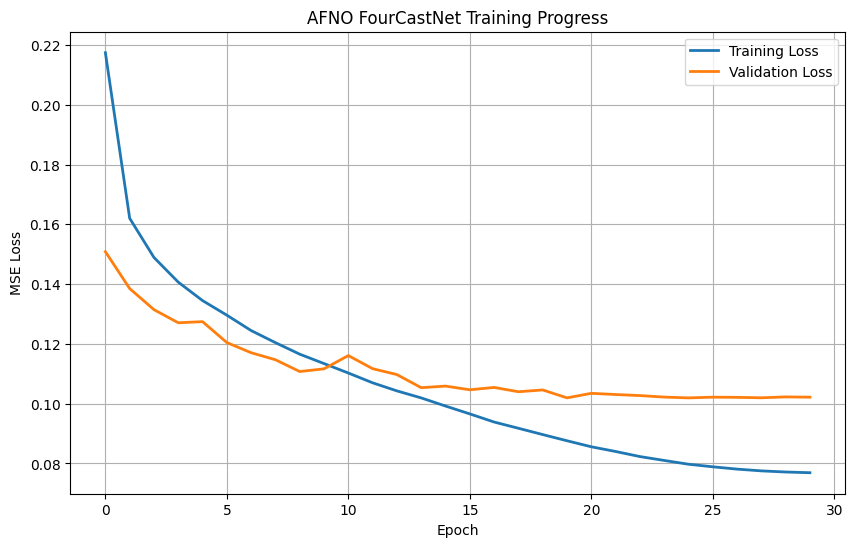

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("AFNO FourCastNet Training Progress")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
import numpy as np

step_rmse = np.zeros(4)

count = 0

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        pred = model(x)

        pred = pred.cpu().numpy()
        y = y.numpy()

        for step in range(4):

            step_rmse[step] += np.sqrt(
                np.mean(
                    (
                        pred[:,step]
                        -
                        y[:,step]
                    )**2
                )
            )

        count += 1

step_rmse /= count

print(step_rmse)

[0.19222984 0.28380491 0.36506995 0.42777163]


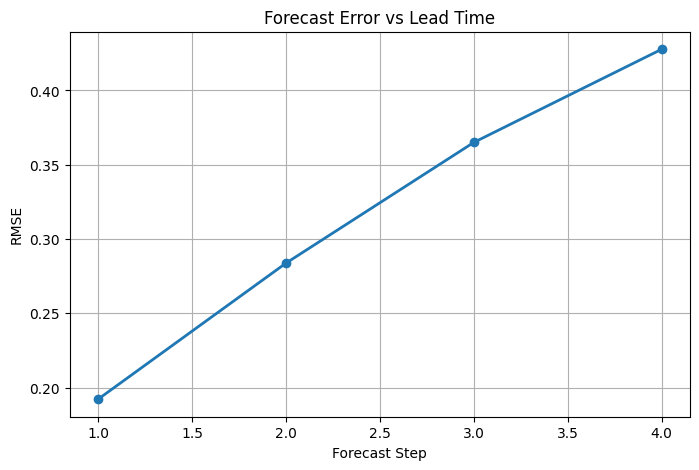

In [70]:
plt.figure(figsize=(8,5))

plt.plot(
    [1,2,3,4],
    step_rmse,
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast Step")
plt.ylabel("RMSE")
plt.title("Forecast Error vs Lead Time")

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/horizon_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
model.eval()

x,y = test_dataset[0]

x = x.unsqueeze(0).to(device)

with torch.no_grad():

    pred = model(x)

pred = pred.squeeze(0).cpu().numpy()
y = y.numpy()

In [72]:
step = 0
var = 2

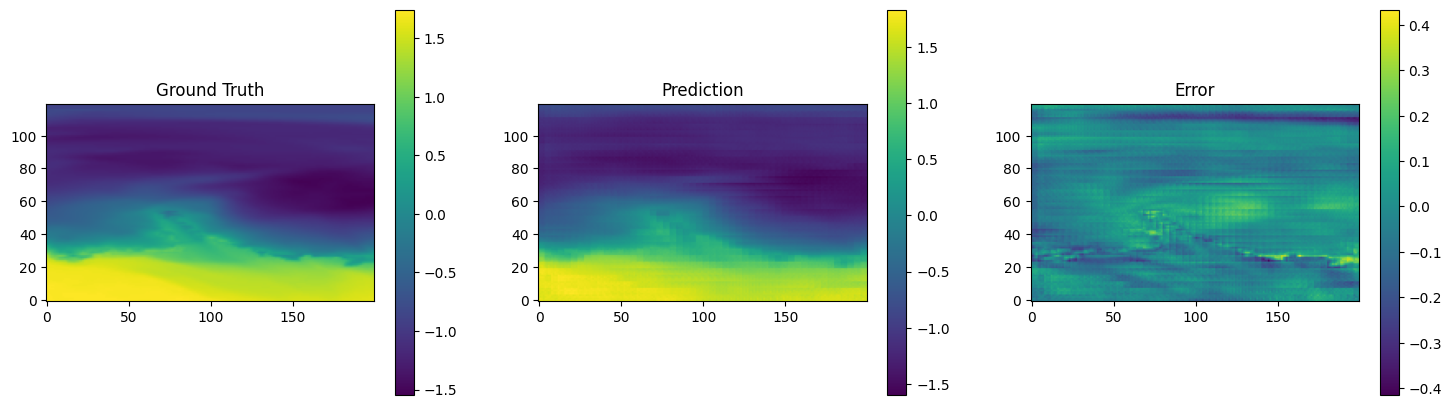

In [73]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

im0 = ax[0].imshow(
    y[step,var],
    origin="lower"
)

ax[0].set_title(
    "Ground Truth"
)

plt.colorbar(
    im0,
    ax=ax[0]
)

im1 = ax[1].imshow(
    pred[step,var],
    origin="lower"
)

ax[1].set_title(
    "Prediction"
)

plt.colorbar(
    im1,
    ax=ax[1]
)

im2 = ax[2].imshow(
    pred[step,var]
    -
    y[step,var],
    origin="lower"
)

ax[2].set_title(
    "Error"
)

plt.colorbar(
    im2,
    ax=ax[2]
)

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/truth_pred_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

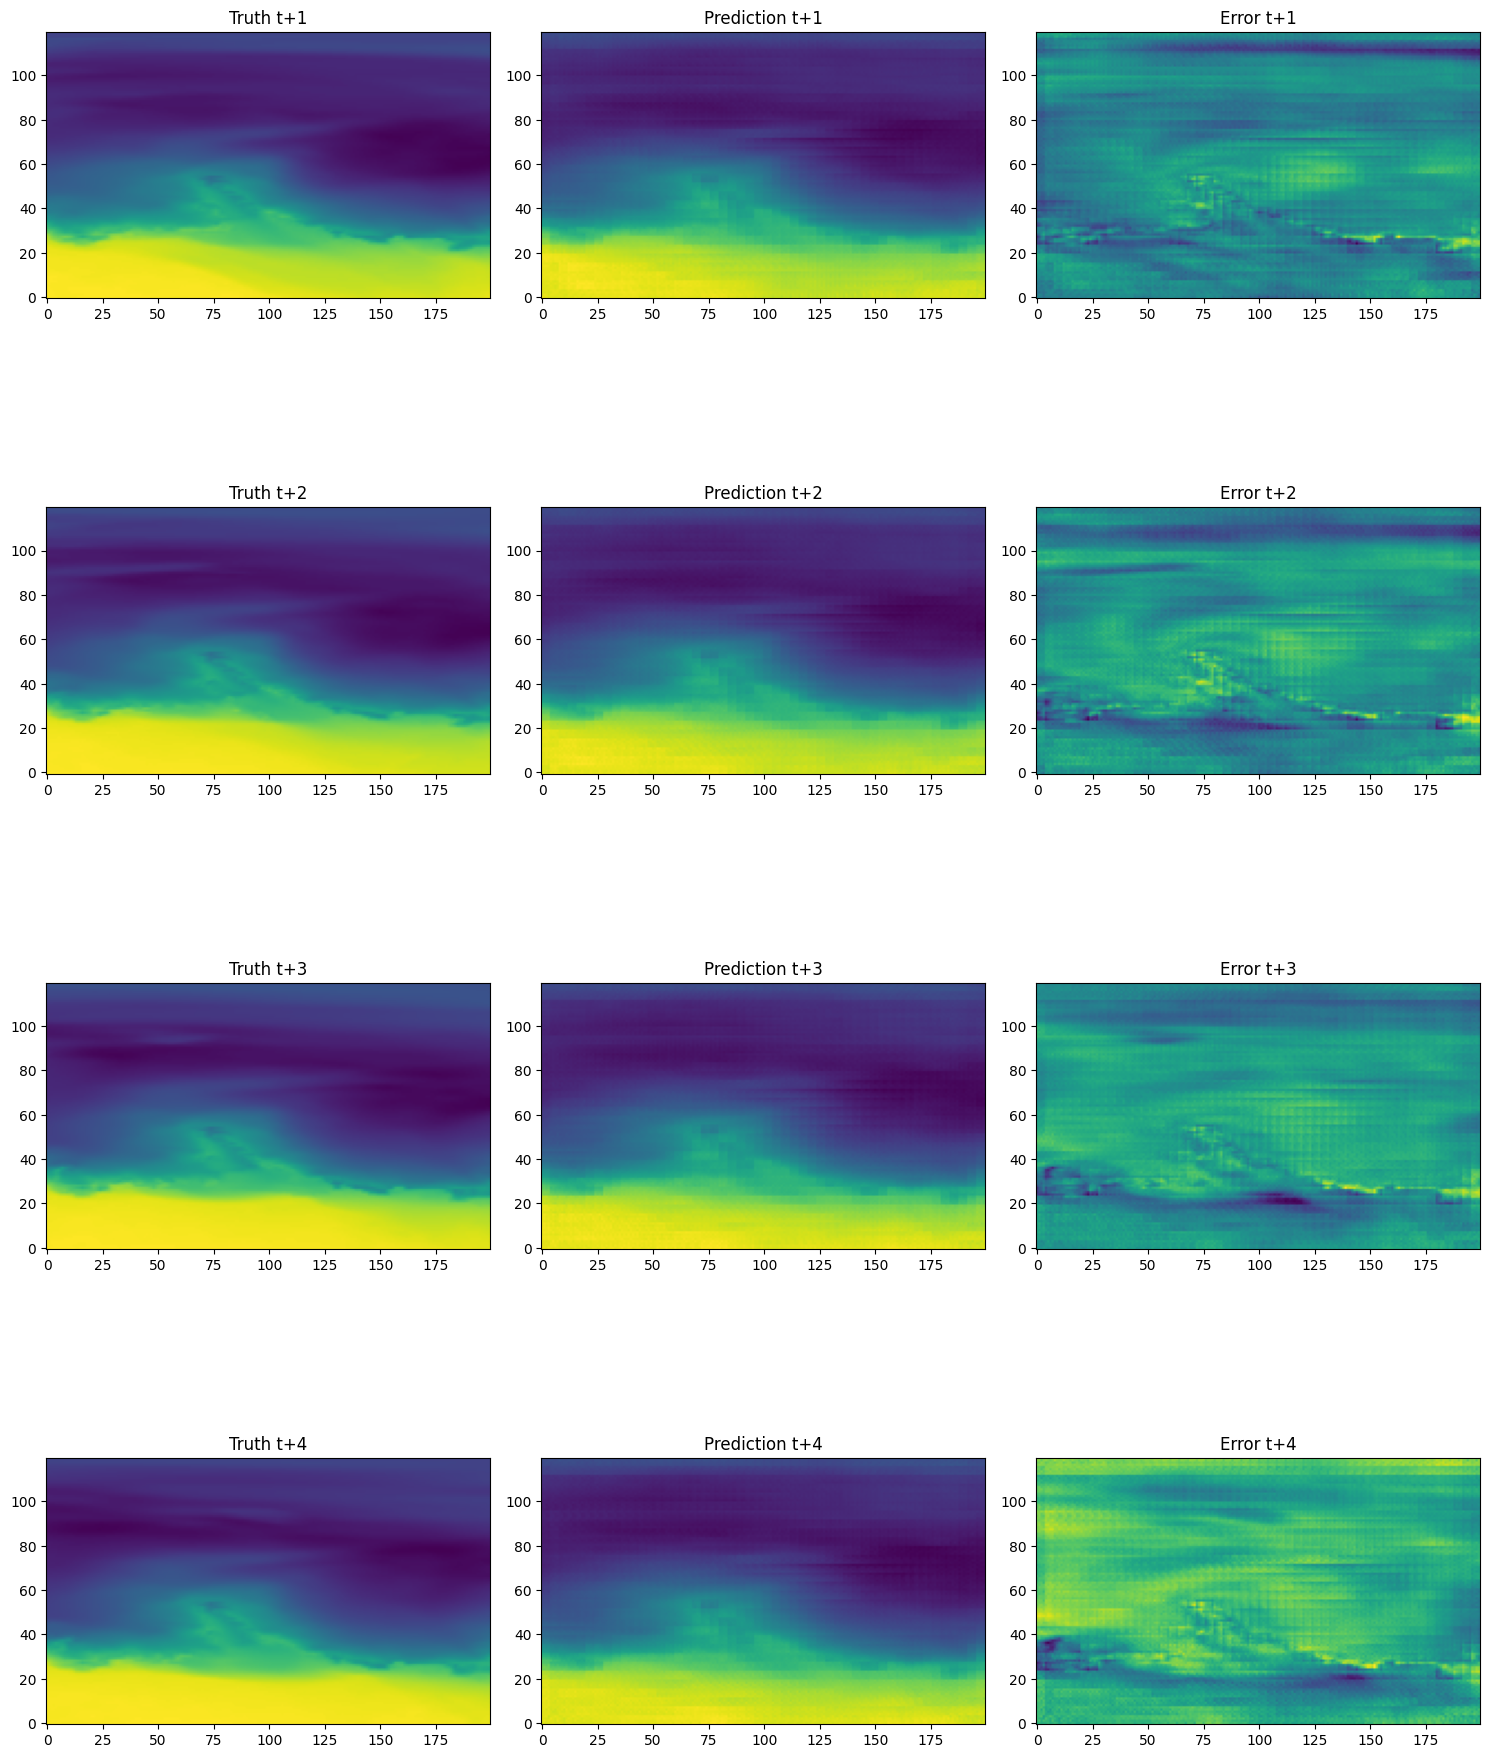

In [74]:
fig, ax = plt.subplots(
    4,
    3,
    figsize=(15,20)
)

for step in range(4):

    truth = y[step,2]

    prediction = pred[step,2]

    error = prediction - truth

    ax[step,0].imshow(
        truth,
        origin="lower"
    )

    ax[step,0].set_title(
        f"Truth t+{step+1}"
    )

    ax[step,1].imshow(
        prediction,
        origin="lower"
    )

    ax[step,1].set_title(
        f"Prediction t+{step+1}"
    )

    ax[step,2].imshow(
        error,
        origin="lower"
    )

    ax[step,2].set_title(
        f"Error t+{step+1}"
    )

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/full_forecast_grid.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
import numpy as np

var_names = [
    "u10",
    "v10",
    "t2m",
    "msl"
]

var_rmse = np.zeros(4)

count = 0

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        pred = model(x)

        pred = pred.cpu().numpy()
        y = y.numpy()

        for v in range(4):

            var_rmse[v] += np.sqrt(
                np.mean(
                    (
                        pred[:,:,v]
                        -
                        y[:,:,v]
                    )**2
                )
            )

        count += 1

var_rmse /= count

print(var_rmse)

[0.38915104 0.43443596 0.12045656 0.27596449]


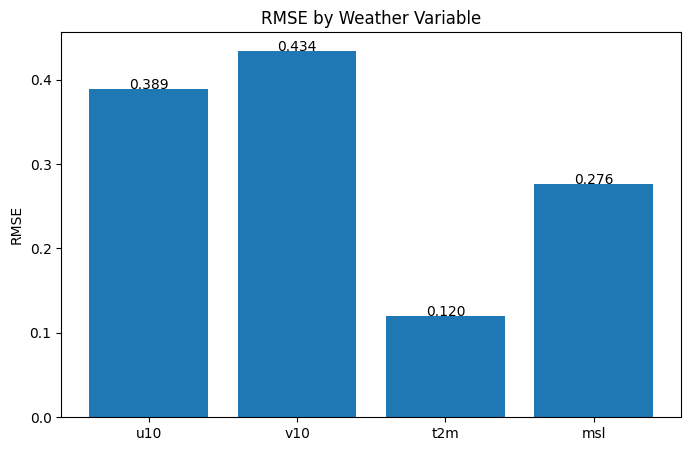

In [76]:
  plt.figure(figsize=(8,5))

bars = plt.bar(
    var_names,
    var_rmse
)

plt.ylabel("RMSE")
plt.title("RMSE by Weather Variable")

for bar,val in zip(bars,var_rmse):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        val,
        f"{val:.3f}",
        ha="center"
    )

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/variable_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
errors = []

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        pred = model(x)

        pred = pred.cpu().numpy()

        errors.append(
            (pred - y.numpy()).ravel()
        )

errors = np.concatenate(errors)

print(errors.shape)

(420096000,)


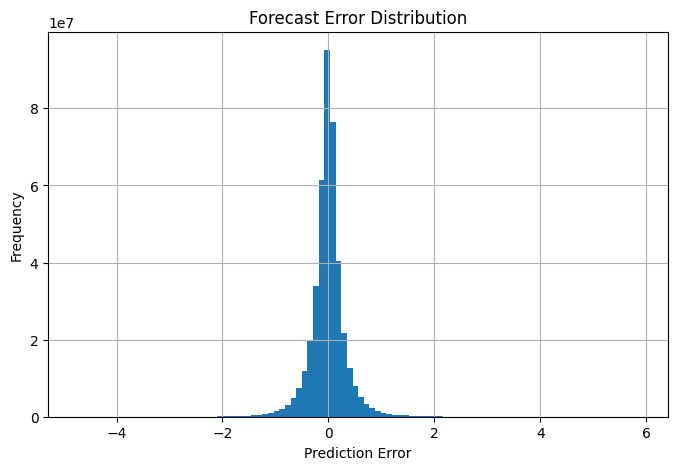

In [78]:
plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=100
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title(
    "Forecast Error Distribution"
)

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/error_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
true_vals = []
pred_vals = []

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        pred = model(x)

        pred = pred.cpu().numpy()

        true_vals.append(
            y.numpy()[:,:,2].ravel()
        )

        pred_vals.append(
            pred[:,:,2].ravel()
        )

true_vals = np.concatenate(true_vals)
pred_vals = np.concatenate(pred_vals)

In [80]:
idx = np.random.choice(
    len(true_vals),
    20000,
    replace=False
)

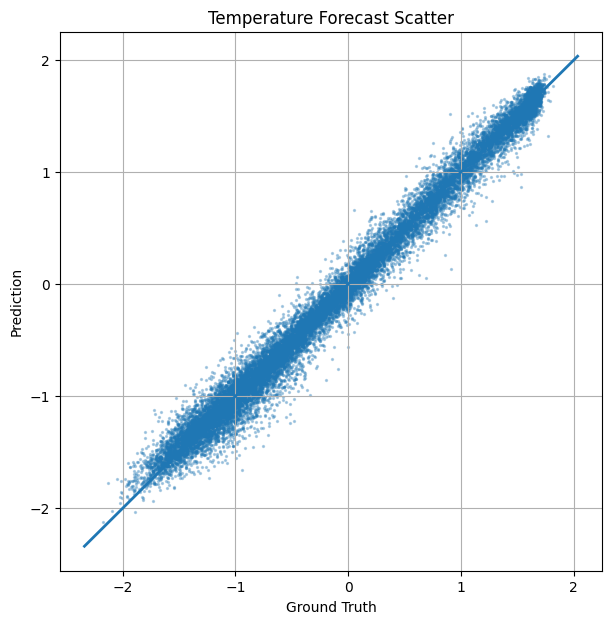

In [81]:
plt.figure(figsize=(7,7))

plt.scatter(
    true_vals[idx],
    pred_vals[idx],
    s=2,
    alpha=0.3
)

mn = min(
    true_vals.min(),
    pred_vals.min()
)

mx = max(
    true_vals.max(),
    pred_vals.max()
)

plt.plot(
    [mn,mx],
    [mn,mx],
    linewidth=2
)

plt.xlabel("Ground Truth")
plt.ylabel("Prediction")

plt.title(
    "Temperature Forecast Scatter"
)

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/scatter_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
lat_idx = 60
lon_idx = 100

In [83]:
truth_series = []
pred_series = []

model.eval()

with torch.no_grad():

    for i in range(50):

        x,y = test_dataset[i]

        pred = model(
            x.unsqueeze(0).to(device)
        )

        pred = pred.squeeze(0).cpu().numpy()

        truth_series.append(
            y[0,2,lat_idx,lon_idx]
        )

        pred_series.append(
            pred[0,2,lat_idx,lon_idx]
        )

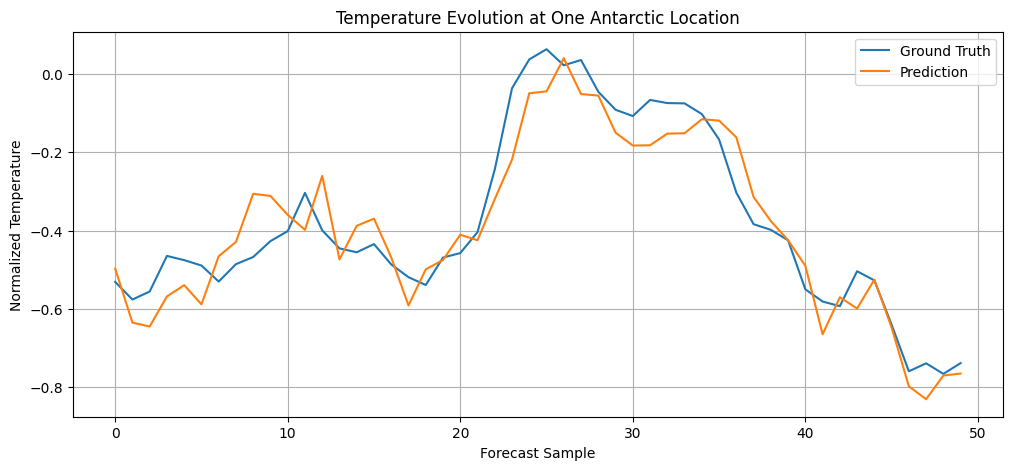

In [84]:
plt.figure(figsize=(12,5))

plt.plot(
    truth_series,
    label="Ground Truth"
)

plt.plot(
    pred_series,
    label="Prediction"
)

plt.xlabel("Forecast Sample")

plt.ylabel("Normalized Temperature")

plt.title(
    "Temperature Evolution at One Antarctic Location"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/time_series_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
error_map = np.zeros(
    (120,200)
)

count = 0

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        pred = model(x)

        pred = pred.cpu().numpy()
        y = y.numpy()

        error_map += np.mean(
            np.abs(
                pred[:,:,2]
                -
                y[:,:,2]
            ),
            axis=(0,1)
        )

        count += 1

error_map /= count

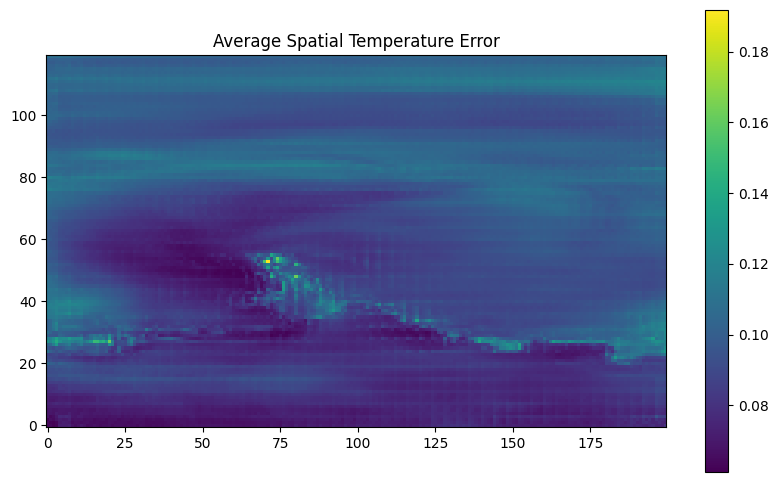

In [86]:
plt.figure(figsize=(10,6))

plt.imshow(
    error_map,
    origin="lower"
)

plt.colorbar()

plt.title(
    "Average Spatial Temperature Error"
)

plt.savefig(
    "/content/drive/MyDrive/FourCastNet_Project/spatial_error_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
!ls -lh /content/drive/MyDrive/FourCastNet_Project/checkpoints | tail

-rw------- 1 root root  15M Jun  1 18:58 epoch_29.pth
-rw------- 1 root root  15M Jun  1 18:37 epoch_2.pth
-rw------- 1 root root  15M Jun  1 18:59 epoch_30.pth
-rw------- 1 root root  15M Jun  1 18:37 epoch_3.pth
-rw------- 1 root root  15M Jun  1 18:38 epoch_4.pth
-rw------- 1 root root  15M Jun  1 18:39 epoch_5.pth
-rw------- 1 root root  15M Jun  1 18:40 epoch_6.pth
-rw------- 1 root root  15M Jun  1 18:41 epoch_7.pth
-rw------- 1 root root  15M Jun  1 18:41 epoch_8.pth
-rw------- 1 root root  15M Jun  1 18:42 epoch_9.pth


In [92]:
!ls -lh /content/drive/MyDrive/FourCastNet_Project/logs

total 1.0K
-rw------- 1 root root 368 Jun  1 18:59 train_losses.npy
-rw------- 1 root root 368 Jun  1 18:59 val_losses.npy


In [93]:
!ls -lh /content/drive/MyDrive/FourCastNet_Project | grep "era5_processed.npy"

-rw------- 1 root root 2.7G Jun  1 18:23 era5_processed.npy
